In [40]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict , Annotated
from pydantic import BaseModel,Field
import operator                             # reducer function for list of scores

In [41]:
load_dotenv()

True

In [42]:
model=ChatGroq(model="llama-3.3-70b-versatile")

In [43]:
class EvaluationSchema(BaseModel):

    feedback : str= Field(description='Detailed feedback on essay')
    score : int = Field(description='Score out of 10',ge=0,le=10)

In [44]:
str_model=model.with_structured_output(EvaluationSchema)

In [45]:
essay=""""Artificial Intelligence is the science and engineering of making intelligent machines, especially intelligent computer programs. It is concerned with getting computers to do tasks that would normally require human intelligence. AI systems are basically software systems (or controllers for robots) that use techniques such as machine learning and deep learning to solve problems in particular domains without hard coding all possibilities (i.e. algorithmic steps) in software. Due to this, AI started showing promising solutions for industry and businesses as well as our daily lives.

Importance and Advantages of Artificial Intelligence
Advances in computing and digital technologies have a direct influence on our lives, businesses and social life. This has influenced our daily routines, such as using mobile devices and active involvement on social media. AI systems are the most influential digital technologies. With AI systems, businesses are able to handle large data sets and provide speedy essential input to operations. Moreover, businesses are able to adapt to constant changes and are becoming more flexible.

By introducing Artificial Intelligence systems into devices, new business processes are opting for the automated process. A new paradigm emerges as a result of such intelligent automation, which now dictates not only how businesses operate but also who does the job. Many manufacturing sites can now operate fully automated with robots and without any human workers. Artificial Intelligence now brings unheard and unexpected innovations to the business world that many organizations will need to integrate to remain competitive and move further to lead the competitors.

Artificial Intelligence shapes our lives and social interactions through technological advancement. There are many AI applications which are specifically developed for providing better services to individuals, such as mobile phones, electronic gadgets, social media platforms etc. We are delegating our activities through intelligent applications, such as personal assistants, intelligent wearable devices and other applications. AI systems that operate household apparatus help us at home with cooking or cleaning.

Future Scope of Artificial Intelligence
In the future, intelligent machines will replace or enhance human capabilities in many areas. Artificial intelligence is becoming a popular field in computer science as it has enhanced humans. Application areas of artificial intelligence are having a huge impact on various fields of life to solve complex problems in various areas such as education, engineering, business, medicine, weather forecasting etc. Many labourers’ work can be done by a single machine. But Artificial Intelligence has another aspect: it can be dangerous for us. If we become completely dependent on machines, then it can ruin our life. We will not be able to do any work by ourselves and get lazy. Another disadvantage is that it cannot give a human-like feeling. So machines should be used only where they are actually required."""

In [46]:
prompt=f'evaluate the following essay on basis of content styling, logic building and give detailed feedback on it and score it out of 10.\n{essay}'

str_model.invoke(prompt)

EvaluationSchema(feedback="The essay provides a good introduction to Artificial Intelligence, its definition, and its applications in various fields. The writer has also highlighted the importance and advantages of AI in businesses and daily lives. However, the essay lacks depth and critical analysis of the subject. The writer could have explored more complex topics such as the ethics of AI, its potential risks, and the need for responsible AI development. The essay also lacks concrete examples and data to support the claims made. The writer's use of transitions and connections between paragraphs is good, but the paragraphs themselves could be more cohesive and well-structured. The conclusion is somewhat abrupt and does not summarize the main points effectively. In terms of style, the writing is clear and concise, but could benefit from more varied sentence structures and vocabulary. Overall, the essay demonstrates a good understanding of the basics of AI, but requires more development

In [47]:
class UPSCState(TypedDict):
    essay: str
    language_feedback : str
    analysis_feedback : str
    clarity_feedback : str

    overall_feedback : str
    individual_scores : Annotated[list[int], operator.add]

In [48]:
def evaluate_language(state:UPSCState):
    prompt=f'evaluate the following essay on basis of language and give detailed feedback on it and score it out of 10.\n{state["essay"]}'
    output=str_model.invoke(prompt)

    return{'language_feedback':output.feedback,'individual_scores':[output.score]}

In [49]:
def evaluate_analysis(state:UPSCState):
    prompt=f'evaluate the following essay on basis of analysis and give detailed feedback on it and score it out of 10.\n{state["essay"]}'
    output=str_model.invoke(prompt)

    return{'analysis_feedback':output.feedback,'individual_scores':[output.score]}

In [50]:
def evaluate_clarity(state:UPSCState):
    prompt=f'evaluate the following essay on basis of clarity and give detailed feedback on it and score it out of 10.\n{state["essay"]}'
    output=str_model.invoke(prompt)

    return{'clarity_feedback':output.feedback,'individual_scores':[output.score]}

In [51]:
def finally_evaluate(state:UPSCState):
    overall_feedback=f'Language Feedback: {state["language_feedback"]}\nAnalysis Feedback: {state["analysis_feedback"]}\nClarity Feedback: {state["clarity_feedback"]}'
    return {'overall_feedback':overall_feedback}

In [52]:
graph=StateGraph(UPSCState)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('finally_evaluate', finally_evaluate)

# edges

graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis') 
graph.add_edge(START,'evaluate_clarity') 

graph.add_edge('evaluate_language','finally_evaluate')
graph.add_edge('evaluate_analysis','finally_evaluate')
graph.add_edge('evaluate_clarity','finally_evaluate')

graph.add_edge('finally_evaluate',END)

workflow=graph.compile()

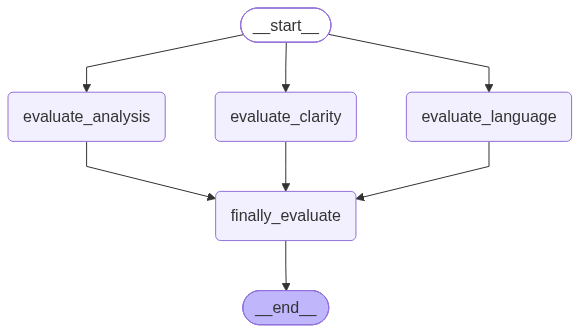

In [53]:
workflow

In [54]:
initial_state={
    'essay': essay

}

workflow.invoke(initial_state)

{'essay': '"Artificial Intelligence is the science and engineering of making intelligent machines, especially intelligent computer programs. It is concerned with getting computers to do tasks that would normally require human intelligence. AI systems are basically software systems (or controllers for robots) that use techniques such as machine learning and deep learning to solve problems in particular domains without hard coding all possibilities (i.e. algorithmic steps) in software. Due to this, AI started showing promising solutions for industry and businesses as well as our daily lives.\n\nImportance and Advantages of Artificial Intelligence\nAdvances in computing and digital technologies have a direct influence on our lives, businesses and social life. This has influenced our daily routines, such as using mobile devices and active involvement on social media. AI systems are the most influential digital technologies. With AI systems, businesses are able to handle large data sets and